# Bühlmann Credibility Model


## 1. Actuarial Theory: First Principles

The Bühlmann model is a "Greatest Accuracy" credibility method. It seeks to find a credibility factor $Z$ that minimizes the mean square error between our estimate and the true (but unknown) risk premium. 

We assume a risk parameter $\Theta$ for each policy holder. The model balances the **Individual Experience** ($\bar{X}$)  and the **Collective Mean**(($\mu$). 


### The Credibility Formula

The credibility premium $P_c$ is defined as:$$P_c = Z\bar{X} + (1-Z)\mu$$Where the credibility factor $Z$ is:$$Z = \frac{n}{n + K}$$

### The Structural Parameters 
To calculate $K$, we need two components: 

1. **Expected Value of Process Variance (EVPV)**: The average variance within each risk group. 
$$s^2 = E[Var(X|\Theta)]$$

2. **Variance of Hypothetical Means (VHM):** The variance between the means of different risk groups. 
$$a = Var(E[X|\Theta])$$

3. **The Bühlmann Constant:**
$$K = \frac{s^2}{a}$$

## 2. Real-World Application: Kenyan Motor Fleet Underwriting

Imagine your are providing services to 5 different logistics companies in Nairobi. 
You want to price their professional indemnity or motor fleet insurance. 

- **The Problem:** Some fleets are new (small $n$), and their claims experience might be "lucky" (zero claims) rather than safe.

- **The Solution:** Using Bühlmann Credibility, we don't just give a 0% rate to a new fleet. We "shrink" their individual experience toward the industry average based on how much we trust their specific data volume ($n$).

## 3. Example
We have 3 Fleets over 4 years of claims data (in '000 KES):
- **Fleet A:** [120, 110, 150, 130] (Consistent)

- **Fleet B:** [400, 350, 420, 380] (High Risk)

- **Fleet C:** [50, 60, 40, 50] (Low Risk)

## 4. Python Implementation

#### Data Preparation and Structural Parameters

In [ ]:

import numpy as np
import pandas as pd 

# 1. Setup Data: Rows = Entities (Fleets), Columns = Years
claims_data = np.array([
    [120, 110, 150, 130],
    [400, 350, 420, 380],
    [50, 60, 40, 50]
])

n_groups, n_years = claims_data.shape

# 2. Calculate Statistics per group
group_means = np.mean(claims_data, axis=1)
group_vars = np.var(claims_data, axis=1, ddof=1)


# 3. Calculate Structural Parameters 
mu = np.mean(group_means) # Collective Mean
s2 = np.mean(group_vars) # EPV (Expected Value of Process Variance)
# VHM (Variance of Hypothetical Means) - Adjusted for small sample 
a = np.var(group_means, ddof=1) - (s2 / n_years)
a = max(a, 0) # Variance cannot be negative

K = s2 / a
Z = n_years / (n_years + K)

print(f"Collective Mean (mu): {mu:.2f}")
print(f"EPV (s^2): {s2:.2f}")
print(f"VHM (a): {a:.2f}")
print(f"Bühlmann Constant (K): {K:.2f}")
print(f"Credibility Factor (Z): {Z:.4f}")

Collective Mean (mu): 188.33
EPV (s^2): 416.67
VHM (a): 31147.92
Bühlmann Constant (K): 0.01
Credibility Factor (Z): 0.9967


#### Credibility Premium Calculation

In [ ]:
# 4. Calculate Credibility Premium for each fleet
credibility_premiums = Z * group_means + (1- Z) * mu

results_df = pd.DataFrame({
    "Fleet": ["Fleet A", "Fleet B", "Fleet C"],
    "Historical_Mean": group_means,
    "Credibility_Premium": credibility_premiums
})

print(results_df)

     Fleet  Historical_Mean  Credibility_Premium
0  Fleet A            127.5           127.702764
1  Fleet B            387.5           386.836155
2  Fleet C             50.0            50.461080


#### Visualization of "Shrinkage"

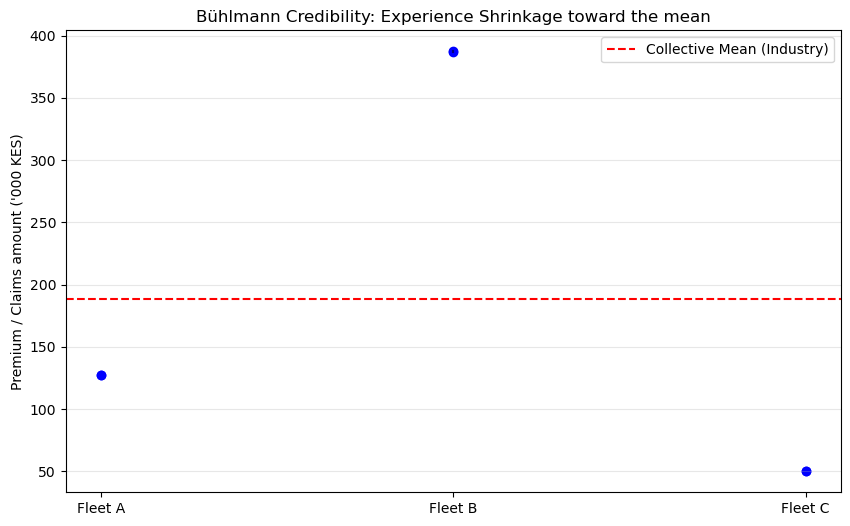

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.axhline(y=mu, color="r", linestyle="--", label="Collective Mean (Industry)")

for i, fleet in enumerate(results_df["Fleet"]):
    plt.scatter([fleet, fleet], [group_means[i], credibility_premiums[i]], color="blue")
    plt.plot([fleet, fleet], [group_means[i], credibility_premiums[i]], "k-", alpha=0.5)

plt.title("Bühlmann Credibility: Experience Shrinkage toward the mean")
plt.ylabel("Premium / Claims amount ('000 KES)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## NOTE: 

In production systems e.g FinTech on InsurTech, $K$ would be a tracked hyperparameter. If $K$ is very large, it indicates that the intra-group variance ($s^2$) is high relative to inter-group variance ($a$), meaning the data is too "noisy" to tryst individual experience ( $Z$ becomes small).

## To Explore
The Bühlmann Credibility model can act as a **Statistical Governor**. While Machine Learning models like XGBoost or Neural Networks are excellent at capturing nonlinearity, they are prone to be "over-responsive" in data-sparse environments. 

### Usage in Reporting & Validation
1. **Shrinkage towards stability**: We apply the credibility factor $Z$ to "shrink" ML predictions toward a long-term industry benchmark. This ensures that a single catastrophic claim for a small client doesn't cause the ML model to generate an unmarketable premium hike. 

2. **Backtesting Credibility**: By comparing the *MSE* or raw ML outputs vs Credibility-weighted outputs over a 3-year rolling window, we can mathematically prove to regulators (e.g, IRA) that our pricing is stable and actuarially sound. 

3. **Outlier Smoothing:** In the automated reporting pipeline, if $Z < 0.3$ (low credibility), the system can trigger an automated "Manual Review" flag, signaling that the ML model is operating in a region where historical data is insufficient for a fully autonomous decision. 